In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from utils import (
    SyntheticLinearDataset, mu_f_linear,
    rademacher_linear_empirical, figures_dir
)

In [2]:
n_features = 64
m_max = 1024
seed = 42
variance_tries = 16

sample_sizes = np.unique(np.geomspace(16, m_max, num=14, dtype=int))

mu_all = np.zeros((len(sample_sizes), variance_tries))
rad_all = np.zeros((len(sample_sizes), variance_tries))

for j, m in enumerate(tqdm(sample_sizes)):
    for t in range(variance_tries):
        ds = SyntheticLinearDataset(
            n=n_features,
            m=m,
            noise_std=0.1,
            seed=seed + variance_tries * j + t,
            row_radius_log_sigma=0.28,
        )
        X, _, _ = ds.sample()
        mu_all[j, t] = mu_f_linear(X)
        rad_all[j, t] = rademacher_linear_empirical(
            X, W=2.0, n_mc=4096,
            rng=np.random.default_rng(seed + variance_tries * j + t),
        )

mu_mean, mu_std = mu_all.mean(axis=1), mu_all.std(axis=1, ddof=1)
rad_mean, rad_std = rad_all.mean(axis=1), rad_all.std(axis=1, ddof=1)

  0%|          | 0/14 [00:00<?, ?it/s]

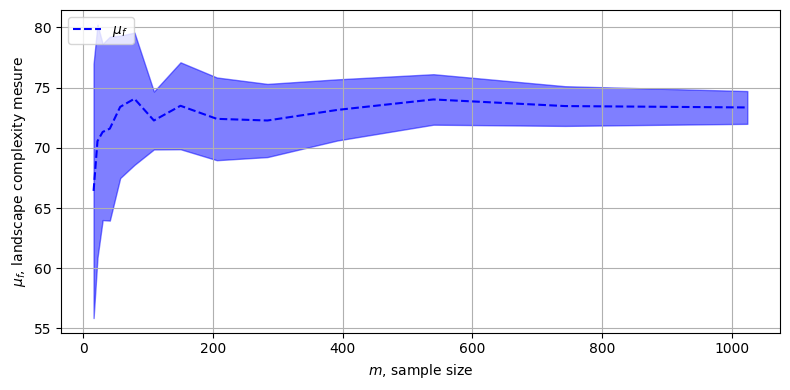

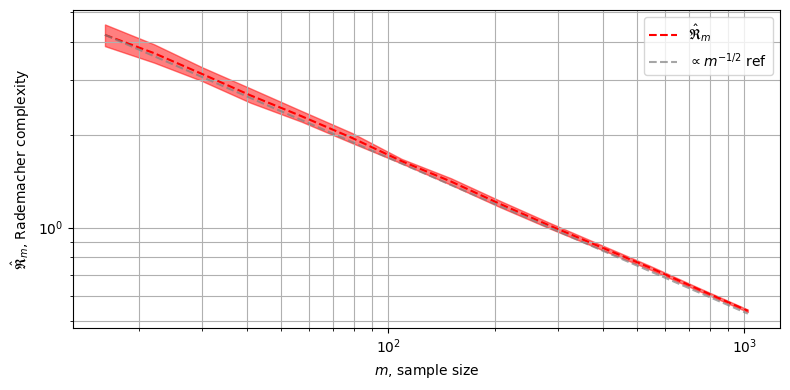

In [3]:
fig_mu, ax_mu = plt.subplots(figsize=(8, 4))
ax_mu.fill_between(
    sample_sizes,
    mu_mean - mu_std,
    mu_mean + mu_std,
    color="blue",
    alpha=0.5,
)
ax_mu.plot(sample_sizes, mu_mean, "--", color="blue", label=r"$\mu_f$")
ax_mu.set_xlabel(r"$m$, sample size")
ax_mu.set_ylabel(r"$\mu_f$, landscape complexity mesure")
ax_mu.grid(True)
ax_mu.legend(loc="upper left")
fig_mu.tight_layout()
fig_mu.savefig(
    figures_dir() / "exp02_linear_sweep_m_mu.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fig_rad, ax_rad = plt.subplots(figsize=(8, 4))
ax_rad.fill_between(
    sample_sizes,
    np.maximum(rad_mean - rad_std, 1e-16),
    rad_mean + rad_std,
    color="red",
    alpha=0.5,
)
ax_rad.loglog(sample_sizes, rad_mean, "--", color="red", label=r"$\hat{\mathfrak{R}}_m$")
ref = rad_mean[0] * np.sqrt(sample_sizes[0]) / np.sqrt(sample_sizes)
ax_rad.loglog(sample_sizes, ref, "--", color="gray", alpha=0.7, label=r"$\propto m^{-1/2}$ ref")
ax_rad.set_xlabel(r"$m$, sample size")
ax_rad.set_ylabel(r"$\hat{\mathfrak{R}}_m$, Rademacher complexity")
ax_rad.legend(loc="upper right")
ax_rad.grid(True, which="both")
fig_rad.tight_layout()
fig_rad.savefig(
    figures_dir() / "exp02_linear_sweep_m_rademacher.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()